#### Stats post-processing

This notebook performs the post-processing of the statistical data. More specifically, it goes through the following steps:
1. reads the `stats1` and `stats2` files of each block and plots any variable
2. computes the total pressure field across the domain, the measurement planes and the mixed out loss
3. plots the isentropic Mach and loss coefficient distributions
4. computes the inlet/outlet angles of the flow.

**Notes**: the notebook relies on adjustments of functions and processing methods written by J. Liu, C. Matar, and L. Zemmour. 

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
import pandas as pd

from scipy.interpolate import splprep, splev
from scipy.interpolate import Rbf

from musicaa_utils import get_block_info, line_interp, mixed_out, plot_grid, read_grid, read_info, read_stats

def rearrange(x,d):
    len_ = d['nx_bl3']+d['nx_bl4']
    # save bl6 coords
    x_ = np.zeros(d['nx_bl6'])
    x_ = x[len_:len_+d['nx_bl6']].copy()
    # rotate array
    x[len_:len_+d['nx_bl7']] = x[-d['nx_bl7']:].copy()
    x[-d['nx_bl6']:] = x_.copy()

    return x

def read_case(input_dir, dict_input, plot_mesh=False):

    print('Reading case from: ', input_dir)

    pitch      = dict_input['pitch']
    x1_samp    = dict_input['x1']
    x2_samp    = dict_input['x2']
    in_blocks  = dict_input['in_blocks']
    out_blocks = dict_input['out_blocks']
    wall_blocks= dict_input['wall_blocks']

    dict_info = read_info(input_dir)
    block_info = get_block_info(input_dir)
    ngh = int(dict_info["ngh"])
    n_block = dict_info["nbloc"]
    Re_in  = dict_info['Reref']
    u_in   = dict_info['Uref']
    p_in   = dict_info['Pref']
    rho_in = dict_info['Roref']
    mu_in  = dict_info['Muref']
    c_in   = dict_info['cref']
    nz     = dict_info['nz_bl1']

    print('Input case info: Re = ', Re_in, ', U = ', u_in, ', p = ', p_in, ', rho = ', rho_in, ', mu = ', mu_in, ', c = ', c_in)

    data = {}
    stats1 = {}
    stats2 = {}
    x_flat   = []
    y_flat   = []

    for bl in range(1, n_block + 1):
        data[bl] = {}
        # read grid
        bl_file = os.path.join(input_dir, f'grid_bl{bl}_ngh{ngh}.bin')
        nx, ny, nz, x, y, z = read_grid(input_dir, bl_file)
        # scale grid
        data[bl]["x"], data[bl]["y"], data[bl]["z"] = x, y, z

        if bl in wall_blocks:
            block_info[f'block_{bl}']['wall'] = True
        else:
            block_info[f'block_{bl}']['wall'] = False

        # Wall location
        block_info[f'block_{bl}']['jmin'] = True
        block_info[f'block_{bl}']['imax'] = False

    # Plot mesh
    if plot_mesh is True:
        plot_grid(input_dir, True, n_bl=n_block, every=5, figsize=(5.2, 3.64))
    
    nw = sum([dict_info[f'nx_bl{bl}'] for bl in wall_blocks])
    
    x1,xw,x1_     = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    y1,yw,y1_     = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    duxw,duyw,dxw = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    dvxw,dvyw,dyw = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    rhow,muw,pw   = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    tau = np.zeros((nw,2,2))

    # The sensors coordinates are also extracted for each block

    sensor = {}
    for bl in range(1, n_block + 1):

        sensor[bl] = []
        nb_pt = block_info[f"block_{bl}"]["nb_points"]
        nb_li = block_info[f"block_{bl}"]["nb_lines"]

        if nb_pt > 0:
            for pt in range(1, nb_pt + 1):
                xs = block_info[f"block_{bl}"][f"point_{pt}"]["nx1"]
                ys = block_info[f"block_{bl}"][f"point_{pt}"]["ny1"]
                sensor[bl].append([xs, ys])
                # print(f"point in block {bl} at indexes {xs, ys}")
        if nb_li > 0:
            for li in range(1, nb_li + 1):
                xs = block_info[f"block_{bl}"][f"line_{li}"]["nx1"]
                ys = block_info[f"block_{bl}"][f"line_{li}"]["ny1"]
                sensor[bl].append([xs, ys])
                # print(f"line in block {bl} at indexes {xs, ys}")

    # Statistics dictionary are created and filled with each block's data
    
    nw_loc = 0
    for bl in range(1, n_block + 1):

        nx, ny = block_info[f"block_{bl}"]["nx"], block_info[f"block_{bl}"]["ny"]
        stats1[bl] = read_stats(os.path.join(input_dir, f"stats1_bl{bl}.bin"), nx, ny)
        stats2[bl] = read_stats(os.path.join(input_dir, f"stats2_bl{bl}.bin"), nx, ny)
        
        cp = stats2[bl]['cp']
        cv = stats2[bl]['cv']
        gamma = cp / cv

        # # isentropic Mach number
        # data[f'block_{bl}']['M_is'] = np.sqrt(2/(gam_in-1)*\
        #       ((p0_in/stats1[bl] ['p'])**((gam_in-1)/gam_in)-1))
        # M_is_flat.append(data[f'block_{bl}']['M_is'].flatten())
        
        data[bl]['rho'] = stats1[bl]['rho']
        data[bl]['x_flat'] = data[bl]['x'].flatten()
        data[bl]['y_flat'] = data[bl]['y'].flatten()
        data[bl]['Mach']   = stats2[bl]['M']
        data[bl]['P0'] = stats1[bl]['p'] * (1 + (gamma - 1) / 2 * data[bl]['Mach']**2)**(gamma / (gamma - 1))
        data[bl]['u'] = stats1[bl]['u']
        data[bl]['v'] = stats1[bl]['v']

        x_flat.append(data[bl]['x'].flatten())
        y_flat.append(data[bl]['y'].flatten())

        if block_info[f'block_{bl}']['wall']:
            if block_info[f'block_{bl}']['jmin']:
                # Wall coordinates
                xw[nw_loc:nw_loc+nx]  = data[bl]['x'][:,0]
                yw[nw_loc:nw_loc+nx]  = data[bl]['y'][:,0]
                # Compute first cell height
                x1_[nw_loc:nw_loc+nx] = data[bl]['x'][:,1]
                y1_[nw_loc:nw_loc+nx] = data[bl]['y'][:,1]
                # Compute wall tangential distance from cell to cell
                dxw[nw_loc:nw_loc+nx] = np.hstack((data[bl]['x'][1:,0]-data[bl]['x'][:-1,0],data[bl]['x'][-2,0]-data[bl]['x'][-1,0]))
                dyw[nw_loc:nw_loc+nx] = np.hstack((data[bl]['y'][1:,0]-data[bl]['y'][:-1,0],data[bl]['y'][-2,0]-data[bl]['y'][-1,0]))
                if bl==6:
                    yw[nw_loc:nw_loc+nx] +=-pitch
                    y1_[nw_loc:nw_loc+nx]+=-pitch
                y1[nw_loc:nw_loc+nx]    = (np.sqrt((x1_-xw)**2+(y1_-yw)**2))[nw_loc:nw_loc+nx]

                # Cf
                rhow[nw_loc:nw_loc+nx] = stats1[bl]['rho'][:,0]
                muw[nw_loc:nw_loc+nx]  = stats1[bl]['mu'][:,0]
                duxw[nw_loc:nw_loc+nx] = stats2[bl]['rho*dux'][:,0]
                duyw[nw_loc:nw_loc+nx] = stats2[bl]['rho*duy'][:,0]
                dvxw[nw_loc:nw_loc+nx] = stats2[bl]['rho*dvx'][:,0]
                dvyw[nw_loc:nw_loc+nx] = stats2[bl]['rho*dvy'][:,0]

                # In cartesian coordinates
                tau[nw_loc:nw_loc+nx,0,0] = (muw*2*duxw/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,0,1] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,1,0] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,1,1] = (muw*2*dvyw/rhow)[nw_loc:nw_loc+nx]

                # # Cf
                # muw[nw_loc:nw_loc+nx]  = stats1[bl]['mu'][:,0]
                # duxw[nw_loc:nw_loc+nx] = np.sqrt(stats2[bl]['dux**2'][:,0])*np.sign(stats2[bl]['p*dux'][:,0])
                # duyw[nw_loc:nw_loc+nx] = np.sqrt(stats2[bl]['duy**2'][:,0])*np.sign(stats2[bl]['p*duy'][:,0])
                # dvxw[nw_loc:nw_loc+nx] = np.sqrt(stats2[bl]['dvx**2'][:,0])*np.sign(stats2[bl]['p*dvx'][:,0])
                # dvyw[nw_loc:nw_loc+nx] = np.sqrt(stats2[bl]['dvy**2'][:,0])*np.sign(stats2[bl]['p*dvy'][:,0])

                # # Cf
                # muw[nw_loc:nw_loc+nx]  = stats1[bl]['mu'][:,0]
                # duxw[nw_loc:nw_loc+nx] = stats2[bl]['p*dux'][:,0]/stats1[bl]['p'][:,0]
                # duyw[nw_loc:nw_loc+nx] = stats2[bl]['p*duy'][:,0]/stats1[bl]['p'][:,0]
                # dvxw[nw_loc:nw_loc+nx] = stats2[bl]['p*dvx'][:,0]/stats1[bl]['p'][:,0]
                # dvyw[nw_loc:nw_loc+nx] = stats2[bl]['p*dvy'][:,0]/stats1[bl]['p'][:,0]

                # # In cartesian coordinates
                # tau[nw_loc:nw_loc+nx,0,0] = (muw*2*duxw)[nw_loc:nw_loc+nx]
                # tau[nw_loc:nw_loc+nx,0,1] = (muw*(duyw+dvxw))[nw_loc:nw_loc+nx]
                # tau[nw_loc:nw_loc+nx,1,0] = (muw*(duyw+dvxw))[nw_loc:nw_loc+nx]
                # tau[nw_loc:nw_loc+nx,1,1] = (muw*2*dvyw)[nw_loc:nw_loc+nx]

                pw[nw_loc:nw_loc+nx] = stats1[bl]['p'][:,0]

                nw_loc+=nx

    xw = rearrange(xw,dict_info)
    yw = rearrange(yw,dict_info)
    pw = rearrange(pw,dict_info)
    tau = rearrange(tau,dict_info)

    xPlot = copy.deepcopy(xw)
    yPlot = copy.deepcopy(yw)

    # Valutazione spline
    tck, u = splprep([xPlot, yPlot], s=0, k=2, per = True)
    
    # Calcolo normali (rispetto alla curva originale xPlot, yPlot)
    dx, dy = splev(u, tck, der=1)
    norm = np.sqrt(dx**2 + dy**2)
    tx, ty = dx/norm, dy/norm
    nx, ny = -dy/norm, dx/norm

    # u_fine = np.linspace(0, 1, 10000)
    # x_s, y_s = splev(u_fine, tck)
    # # Plot
    # plt.figure(figsize=(8, 6))
    # plt.plot(xPlot[10:20], yPlot[10:20], '.', label='Punti')
    # plt.plot(x_s, y_s, '-', label='Spline')
    # plt.quiver(xPlot[10:20], yPlot[10:20], nx[10:20], ny[10:20], color='red', label='Normali')
    # plt.quiver(xPlot[10:20], yPlot[10:20], ny[10:20], -nx[10:20], color='green', label='Normali')
    # plt.axis('equal')
    # plt.show()

    # print(tau.shape)
    # input()
    tauw = []
    for idx in range(len(tau)):
        val = (tau[idx,0,0]*nx[idx]+tau[idx,0,1]*ny[idx])*tx[idx] + (tau[idx,1,0]*nx[idx]+tau[idx,1,1]*ny[idx])*ty[idx]
        # tauw.append(np.sqrt(val*val))
        tauw.append(val)

    data['cf'] = np.array(tauw)/(0.5*rho_in*(u_in**2))

    # union of data
    in_data = {}
    for bl in in_blocks:
        in_data[bl] = data[bl] | stats1[bl] | stats2[bl]

    out_data = {}
    for bl in out_blocks:
        out_data[bl] = data[bl] | stats1[bl] | stats2[bl]

    # The limits along the y axis of both measurement planes are computed 

    # find y corresponding to x1
    x0 = in_data[in_blocks[0]]["x"]
    closest_index = np.argmin(abs(x0[:, 0] - x1_samp))
    y1_samp = in_data[in_blocks[0]]["y"][closest_index, :].min()
    y2_samp = y1_samp + pitch
    # compute interpolation axis
    y_in = np.linspace(y1_samp, y2_samp, 1000)
    # build inlet_lims
    inlet_lims = [x1_samp, y1_samp, x1_samp, y2_samp]
    # print(f"inlet_lims: {inlet_lims}")

    # find y corresponding to x1
    x0 = out_data[out_blocks[0]]["x"]
    closest_index = np.argmin(abs(x0[:, 0] - x2_samp))
    y1_samp = out_data[out_blocks[0]]["y"][closest_index, :].min()
    y2_samp = y1_samp + pitch
    # compute interpolation axis
    y_out = np.linspace(y1_samp, y2_samp, 1000)
    outlet_lims = [x2_samp, y1_samp, x2_samp, y2_samp]
    # print(f"outlet_lims: {outlet_lims}")

    data_inlet = {}
    data_outlet = {}
    for var in ["uu", "vv", "ww", "rhou", "rhov", "rho*uu", "rho*uv", "rho*uw", "p", "T", "M", "cp", "cv"]:
        data_inlet[f"{var}_interp"] = line_interp(in_data, var, inlet_lims, in_blocks)
        data_outlet[f"{var}_interp"] = line_interp(out_data, var, outlet_lims, out_blocks)

    data['gamma']  = np.nanmean(data_inlet["cp_interp"] / data_inlet["cv_interp"])
    # gam1 = gam - 1.0

    data['xw'] = copy.deepcopy(xw)
    data['yw'] = copy.deepcopy(yw)
    data['pw'] = copy.deepcopy(pw)

    in_idx =  np.argwhere(~np.isnan(data_inlet["rhou_interp"]))
    q1 = np.sum(data_inlet["rhou_interp"][in_idx])
    # P1 = np.sum(data_inlet["rhou_interp"][in_idx] * data_inlet["p_interp"][in_idx]) / q1
    P1 = np.mean(data_inlet["p_interp"][in_idx])
    gamma = np.mean(data_inlet["cp_interp"][in_idx] / data_inlet["cv_interp"][in_idx])
    # P01 = np.sum(data_inlet["p_interp"][in_idx] * (1 + (gamma - 1 ) / 2 * data_inlet["M_interp"][in_idx]**2)**(gamma / (gamma - 1)) * data_inlet["rhou_interp"][in_idx]) / q1
    P01 = np.mean(data_inlet["p_interp"][in_idx] * (1 + (gamma - 1 ) / 2 * data_inlet["M_interp"][in_idx]**2)**(gamma / (gamma - 1)) )

    out_idx =  np.argwhere(~np.isnan(data_outlet["rhou_interp"]))
    q2 = np.sum(data_outlet["rhou_interp"][out_idx])
    gamma = np.mean(data_outlet["cp_interp"][out_idx] / data_outlet["cv_interp"][out_idx])
    P02 = np.mean(data_outlet["p_interp"][out_idx] * (1 + (gamma - 1 ) / 2 * data_outlet["M_interp"][out_idx]**2)**(gamma / (gamma - 1)))

    print(f"Loss coefficient w: {(P01 - P02) / (P01 - P1)}; Gamma: {gamma}")

    data['Loss'] = (P01 - data_outlet["p_interp"][out_idx] * (1 + (gamma - 1 ) / 2 * data_outlet["M_interp"][out_idx]**2)**(gamma / (gamma - 1))) / (P01 - P1)
    data['M_is'] = np.sqrt(2/(data['gamma']-1)*((P01/pw)**((data['gamma']-1)/data['gamma'])-1))
    data['P01']  = P01
    data['yLoss'] = y_out[out_idx]

    results = {'data_inlet': data_inlet,
               'data_outlet': data_outlet,
               'stats1': stats1,
               'stats2': stats2,
               'data': data,
               'inlet_lims': inlet_lims,
               'outlet_lims': outlet_lims,
               'y_out': y_out,
               'n_block': n_block,
               'sensor': sensor}

    return results

In [18]:
fs = 9
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": fs,
    'legend.fontsize': fs, 
    "axes.titlesize": fs,
    "axes.labelsize": fs
})


figsize = (5.2, 3.64)
lw = 0.8

dict_input_case = {'pitch': 40.39, 'cax': 1, 'x1': -20.108296, 'x2': 87.25188, 'in_blocks': [1, 2], 'out_blocks': [8, 9], 'wall_blocks': [3, 4, 7, 6]}

# input_dir_ADP_b = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_baseline/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
# input_dir_OP1_b = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_baseline/MUSICAA/musicaa_g0_c0/OP1" # "OP1"
# input_dir_OP2_b = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_baseline/MUSICAA/musicaa_g0_c0/OP2" # "OP2"

input_dir_ADP_pok = "/home/mciarlatani/Irene/validation_cases/deltaP_good/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
input_dir_ADP_fine = "/home/mciarlatani/Irene/validation_cases/deltaP_fine/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
# input_dir_ADP_p2 = "/home/mciarlatani/Irene/validation_cases/deltaP_p2/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
# input_dir_ADP_p10 = "/home/mciarlatani/Irene/validation_cases/deltaP_p10/MUSICAA/musicaa_g0_c0/ADP" # "ADP"

input_dir_OP1_pok = "/home/mciarlatani/Irene/validation_cases/deltaP_good/MUSICAA/musicaa_g0_c0/OP1" # "OP1"
input_dir_OP1_fine = "/home/mciarlatani/Irene/validation_cases/deltaP_fine/MUSICAA/musicaa_g0_c0/OP1" # "OP1"
# input_dir_OP1_p2 = "/home/mciarlatani/Irene/validation_cases/deltaP_p2/MUSICAA/musicaa_g0_c0/OP1" # "OP1"
# input_dir_OP1_p10 = "/home/mciarlatani/Irene/validation_cases/deltaP_p10/MUSICAA/musicaa_g0_c0/OP1" # "OP1"

input_dir_OP2_pok = "/home/mciarlatani/Irene/validation_cases/deltaP_good/MUSICAA/musicaa_g0_c0/OP2" # "OP2"
input_dir_OP2_fine = "/home/mciarlatani/Irene/validation_cases/deltaP_fine/MUSICAA/musicaa_g0_c0/OP2" # "OP2"
# input_dir_OP2_n2 = "/home/mciarlatani/Irene/validation_cases/deltaP_n2/MUSICAA/musicaa_g0_c0/OP2" # "OP2"
# input_dir_OP2_n10 = "/home/mciarlatani/Irene/validation_cases/deltaP_n10/MUSICAA/musicaa_g0_c0/OP2" # "OP2"

In [19]:
ADP_pok = read_case(input_dir_ADP_pok, dict_input_case)
OP1_pok = read_case(input_dir_OP1_pok, dict_input_case)
OP2_pok = read_case(input_dir_OP2_pok, dict_input_case)

ADP_fine = read_case(input_dir_ADP_fine, dict_input_case)
OP1_fine = read_case(input_dir_OP1_fine, dict_input_case)
OP2_fine = read_case(input_dir_OP2_fine, dict_input_case)

Reading case from:  /home/mciarlatani/Irene/validation_cases/deltaP_good/MUSICAA/musicaa_g0_c0/ADP
Input case info: Re =  175188.3829013505 , U =  206.6753636539434 , p =  18416.6 , rho =  0.2192615365361206 , mu =  1.810689152665445e-05 , c =  342.9158182411538


/tmp/ipykernel_180766/1518154284.py:160: RuntimeWarning: invalid value encountered in divide
  tau[nw_loc:nw_loc+nx,0,0] = (muw*2*duxw/rhow)[nw_loc:nw_loc+nx]
/tmp/ipykernel_180766/1518154284.py:161: RuntimeWarning: invalid value encountered in divide
  tau[nw_loc:nw_loc+nx,0,1] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
/tmp/ipykernel_180766/1518154284.py:162: RuntimeWarning: invalid value encountered in divide
  tau[nw_loc:nw_loc+nx,1,0] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
/tmp/ipykernel_180766/1518154284.py:163: RuntimeWarning: invalid value encountered in divide
  tau[nw_loc:nw_loc+nx,1,1] = (muw*2*dvyw/rhow)[nw_loc:nw_loc+nx]


Loss coefficient w: 0.037908405875549896; Gamma: 1.4000000000000061
Reading case from:  /home/mciarlatani/Irene/validation_cases/deltaP_good/MUSICAA/musicaa_g0_c0/OP1


/tmp/ipykernel_180766/1518154284.py:288: RuntimeWarning: invalid value encountered in sqrt
  data['M_is'] = np.sqrt(2/(data['gamma']-1)*((P01/pw)**((data['gamma']-1)/data['gamma'])-1))


Input case info: Re =  175188.3829013505 , U =  206.6753636539434 , p =  18416.6 , rho =  0.2192615365361206 , mu =  1.810689152665445e-05 , c =  342.9158182411538
Loss coefficient w: 0.05074694149748184; Gamma: 1.3999999999999908
Reading case from:  /home/mciarlatani/Irene/validation_cases/deltaP_good/MUSICAA/musicaa_g0_c0/OP2
Input case info: Re =  175188.3829013505 , U =  206.6753636539434 , p =  18416.6 , rho =  0.2192615365361206 , mu =  1.810689152665445e-05 , c =  342.9158182411538
Loss coefficient w: 0.044140503815800855; Gamma: 1.3999999999999913
Reading case from:  /home/mciarlatani/Irene/validation_cases/deltaP_fine/MUSICAA/musicaa_g0_c0/ADP
Input case info: Re =  175188.3829013505 , U =  206.6753636539434 , p =  18416.6 , rho =  0.2192615365361206 , mu =  1.810689152665445e-05 , c =  342.9158182411538
Loss coefficient w: 0.041182403195933574; Gamma: 1.4000000000000035
Reading case from:  /home/mciarlatani/Irene/validation_cases/deltaP_fine/MUSICAA/musicaa_g0_c0/OP1
Input ca

In [20]:
to_plot=[{'results':ADP_pok,'line':'--','color':'tab:blue','label':'ADP coarse','p':16257.9872},
         {'results':ADP_fine,'line':'-','color':'tab:blue','label':'ADP fine','p':16257.9872},
         {'results':OP1_pok,'line':'--','color':'tab:orange','label':'OP1 coarse','p':16729.0556},
         {'results':OP1_fine,'line':'-','color':'tab:orange','label':'OP1 fine','p':16729.0556},
         {'results':OP2_pok,'line':'--','color':'tab:green','label':'OP2 coarse','p':16008.6333},
         {'results':OP2_fine,'line':'-','color':'tab:green','label':'OP2 fine','p':15958.633}]

# to_plot=[{'results':ADP_pok,'line':'--','color':'tab:blue','label':'ADP coarse','p':16257.9872}]

Mean Mach at inlet for ADP coarse: 0.6023985509890561
Mean Mach at inlet for ADP fine: 0.5998612741166076
Mean Mach at inlet for OP1 coarse: 0.588684541876004
Mean Mach at inlet for OP1 fine: 0.5884017058363521
Mean Mach at inlet for OP2 coarse: 0.6030010471911498
Mean Mach at inlet for OP2 fine: 0.6020876316998027


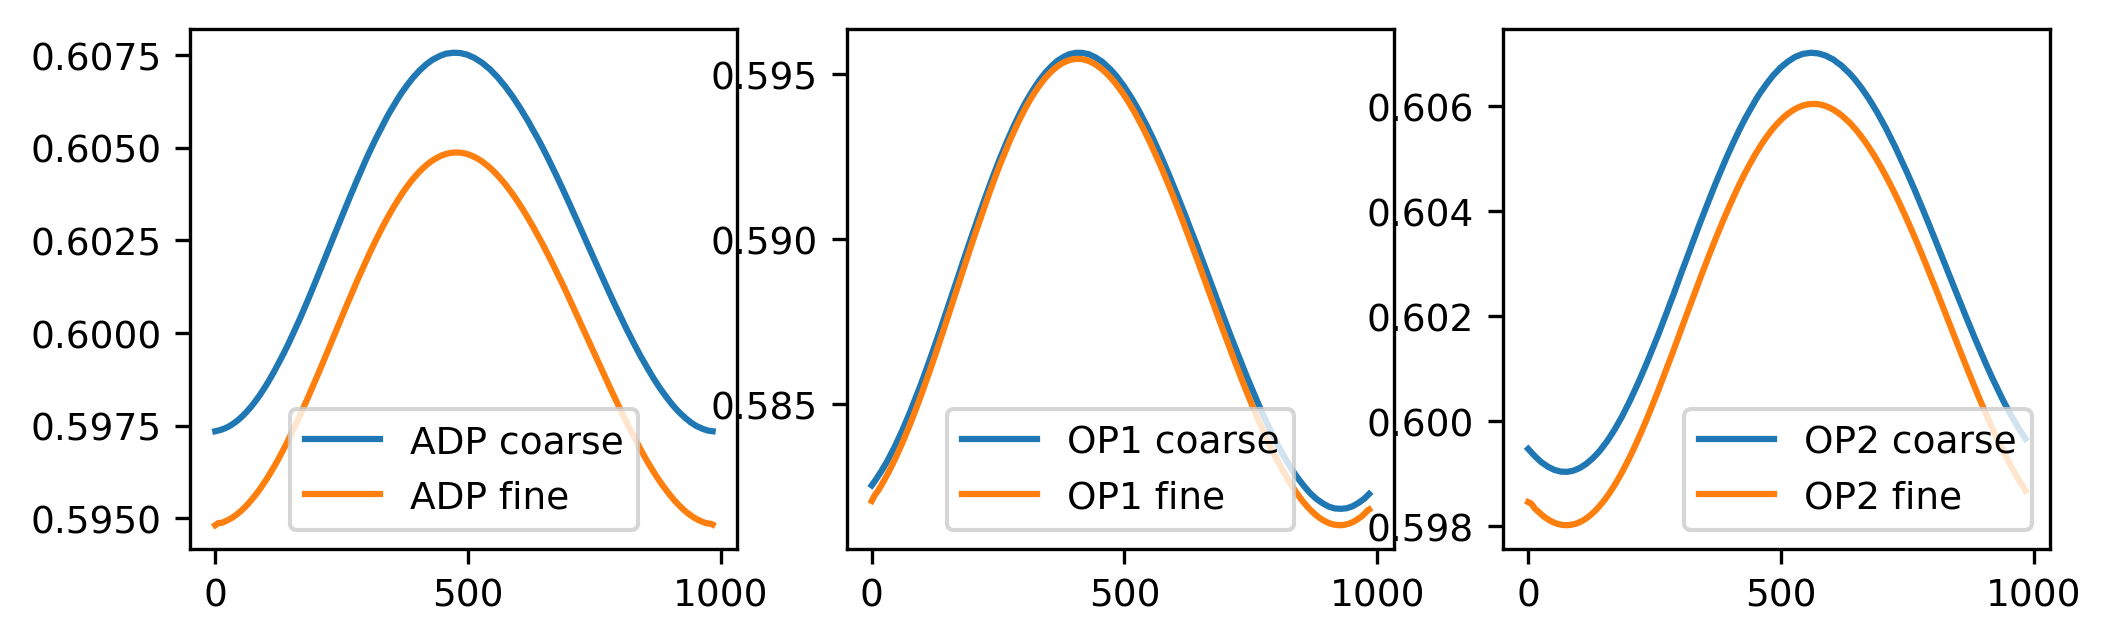

In [21]:

fig = plt.figure(figsize=(8,2.25))

xADP, xOP1, xOP2 = [], [], []
yADP, yOP1, yOP2 = [], [], []

for ddd in to_plot: 

    M_mean = np.nanmean(ddd["results"]["data_inlet"]["M_interp"])

    print(f'Mean Mach at inlet for {ddd["label"]}: {M_mean}')
    
    color, line, lab = ddd['color'], ddd['line'], ddd['label']

    if 'ADP' in lab:
        ax = plt.subplot(1, 3, 1)
        xADP.append(M_mean)
        yADP.append(ddd['p'])
    elif 'OP1' in lab:
        ax = plt.subplot(1, 3, 2)
        xOP1.append(M_mean)
        yOP1.append(ddd['p'])
    elif 'OP2' in lab:
        ax = plt.subplot(1, 3, 3)
        xOP2.append(M_mean)
        yOP2.append(ddd['p'])
    
    ax.plot(ddd['results']['data_inlet']['M_interp'][:-15], label=lab)

    plt.legend()

# plt.figure(figsize=(5,5))
# plt.plot(xADP,yADP,'-o',label='ADP')
# plt.plot(xOP1,yOP1,'-o',label='OP1')
# plt.plot(xOP2,yOP2,'-o',label='OP2')
# plt.legend()

# plt.show()

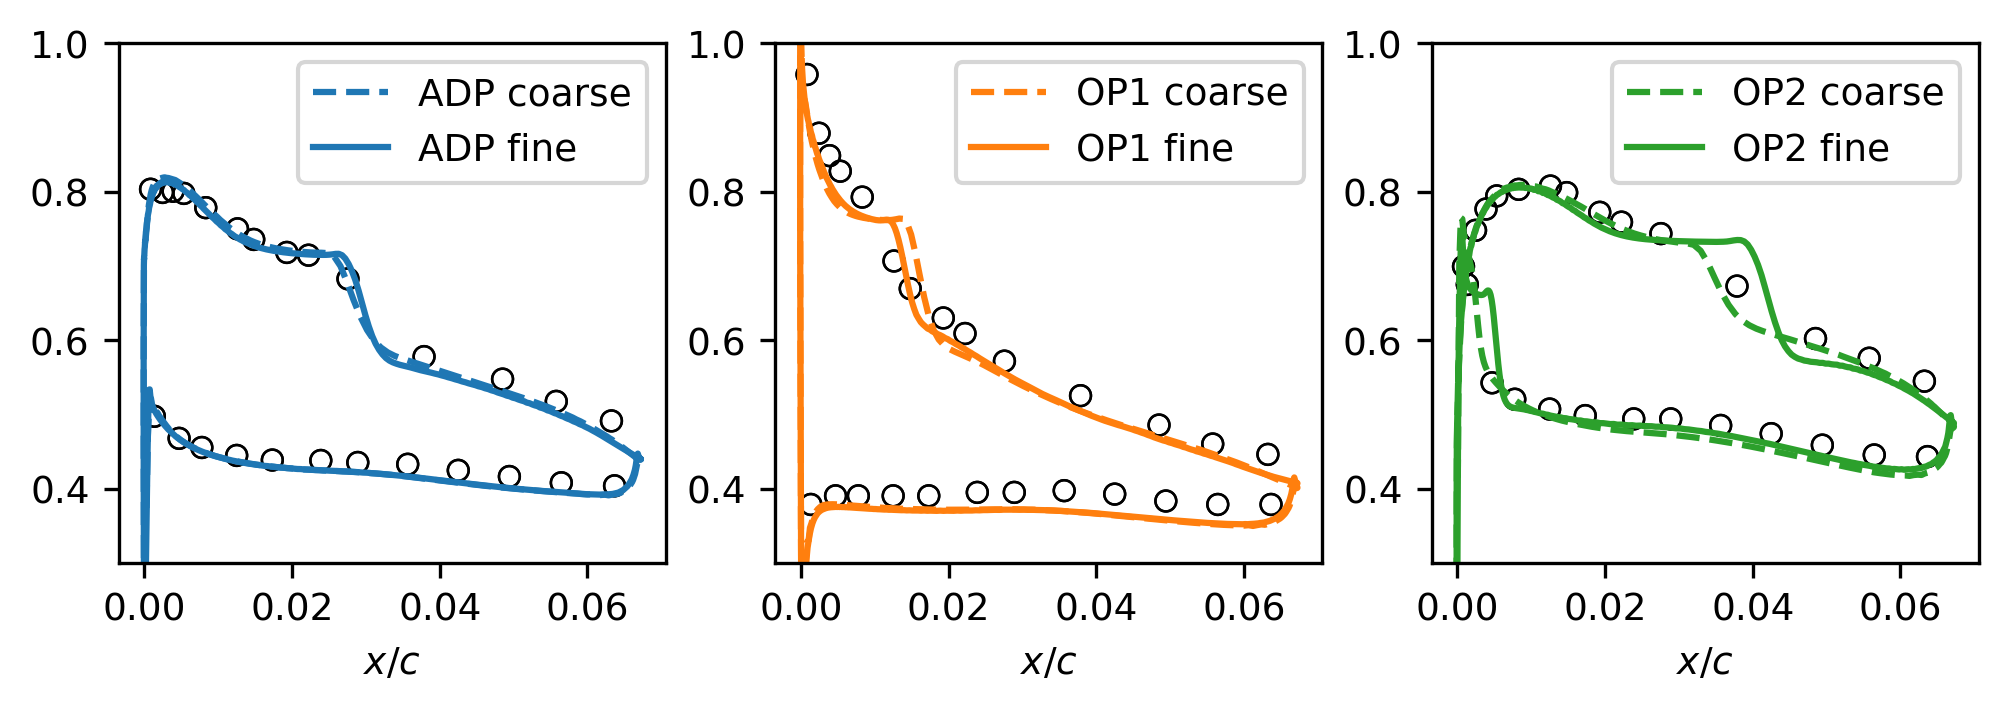

In [22]:
fig = plt.figure(figsize=(8,2.25))

for ddd in to_plot:
    
    color, line, lab = ddd['color'], ddd['line'], ddd['label']

    if 'ADP' in lab:
        ax = plt.subplot(1, 3, 1)
        DLR_data = pd.read_csv('./DLRMisADPSHAREPOINT.csv')
    elif 'OP1' in lab:
        ax = plt.subplot(1, 3, 2)
        DLR_data = pd.read_csv('./DLRMisOP1SHAREPOINT.csv')
    elif 'OP2' in lab:
        ax = plt.subplot(1, 3, 3)
        DLR_data = pd.read_csv('./DLRMisOP2SHAREPOINT.csv')
    
    # ax.plot(elem['data']['xw'], elem['data']['M_is'], label=lab, color=color, linestyle=line, linewidth=lw)
    xw, yw = ddd['results']['data']['xw']/1000, ddd['results']['data']['yw']/1000
    # xPlot = np.cos(np.arctan(yw/xw)-np.pi*16.04/180)*np.sqrt(xw**2+yw**2)/70
    # xPlot = (xw*np.cos(np.pi*16.04/180)+yw*np.sin(np.pi*16.04/180))/70

    # xtilde = (xw ** 2 + yw ** 2) ** 0.5 * np.cos(np.arctan2(yw, xw) - np.deg2rad(16.04))
    # xtilde = (xtilde-xtilde.min())/(xtilde.max()-xtilde.min())

    ax.plot(xw, ddd['results']['data']['M_is'], label=lab, color=color, linestyle=line)
    ax.scatter(DLR_data['x'].to_numpy(), DLR_data['y'].to_numpy(), s=25, marker='o', lw=0.6, color='k', facecolors='none')

    # if idx == 1:
    #     ax.set_ylabel(r'$M_{is}^{ADP}$')
    # if idx == 2:
    #     ax.set_ylabel(r'$M_{is}^{OP1}$')
    #     ax.set_yticklabels([])
    # if idx == 3:
    #     ax.set_ylabel(r'$M_{is}^{OP2}$')
    #     ax.set_yticklabels([])
    #     # ax.legend(frameon=True,framealpha=0).get_frame().set_edgecolor("none")

    ax.set_ylim(0.3, 1.0)
    # ax.set_xlim(0, 1.0)
    # ax.set_xlabel('$\\bar{x}$ [-]')
    ax.set_xlabel('$x/c$')
    plt.legend()

plt.savefig('Mis_comparison.pdf',bbox_inches='tight')

Mixedout loss for LES ADP coarse: 0.03783274039476067
Mixedout loss for DLR ADP coarse: 0.05203818181818183
Mixedout loss for LES ADP fine: 0.04110012067206444
Mixedout loss for DLR ADP fine: 0.05203818181818183
Mixedout loss for LES OP1 coarse: 0.05064565019708826
Mixedout loss for DLR OP1 coarse: 0.07331454545454544
Mixedout loss for LES OP1 fine: 0.04988958667884989
Mixedout loss for DLR OP1 fine: 0.07331454545454544
Mixedout loss for LES OP2 coarse: 0.04405239901776538
Mixedout loss for DLR OP2 coarse: 0.05872
Mixedout loss for LES OP2 fine: 0.05607897223190206
Mixedout loss for DLR OP2 fine: 0.05872


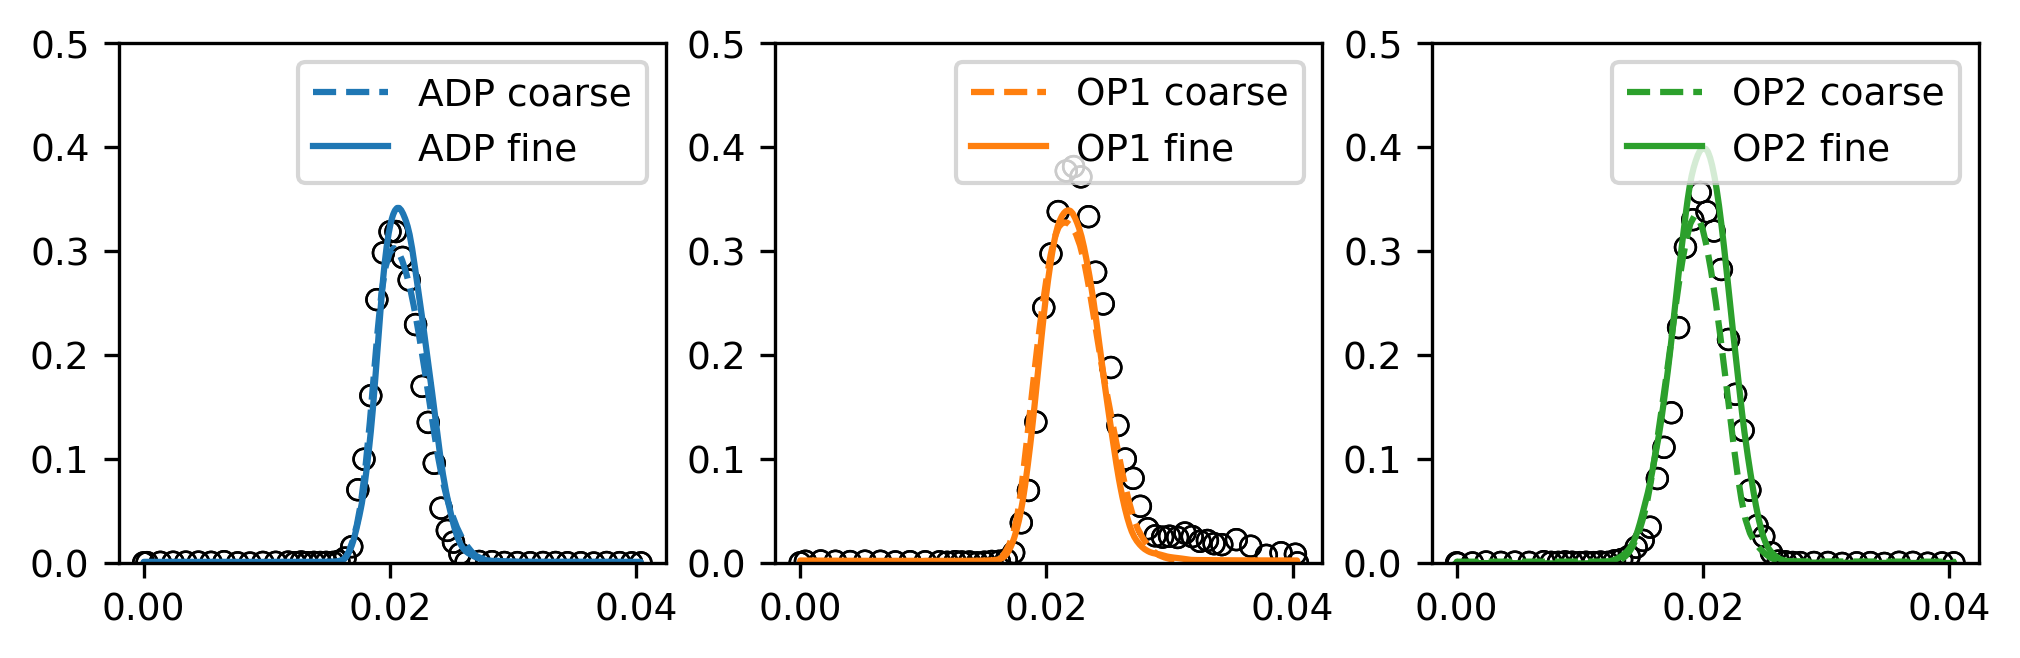

In [47]:
fig = plt.figure(figsize=(8,2.25))

for ddd in to_plot:
    
    color, line, lab = ddd['color'], ddd['line'], ddd['label']

    if 'ADP' in lab:
        ax = plt.subplot(1, 3, 1)
        DLR_data = pd.read_csv('./DLRLossADPSHAREPOINT.csv')
        delta = 0.0183
    elif 'OP1' in lab:
        ax = plt.subplot(1, 3, 2)
        DLR_data = pd.read_csv('./DLRLossOP1SHAREPOINT.csv')
        delta = 0.0183
    elif 'OP2' in lab:
        ax = plt.subplot(1, 3, 3)
        DLR_data = pd.read_csv('./DLRLossOP2SHAREPOINT.csv')
        delta = 0.0183


    idx_TE = np.argmax(ddd['results']['data']['xw'])-3
    y_TE = ddd['results']['data']['yw'][idx_TE]/1000

    xPlotLES = ((ddd['results']['data']['yLoss']/1000)%0.04039).flatten()
    yPlotLES = ddd['results']['data']['Loss'].flatten()
    idx_sort = np.argsort(xPlotLES)
    yPlotLES = np.concatenate(([0], yPlotLES[idx_sort], [0]))
    xPlotLES = np.concatenate(([0], xPlotLES[idx_sort], [0.04039]))
    
    xPlotDLR = -DLR_data['x'].to_numpy() * 0.04039 + delta
    yPlotDLR = DLR_data['y'].to_numpy()
    mask = (xPlotDLR >= 0) & (xPlotDLR <= 0.04039)
    xPlotDLR = copy.deepcopy(xPlotDLR[mask])
    yPlotDLR = copy.deepcopy(yPlotDLR[mask])
    idx_sort = np.argsort(xPlotDLR)
    yPlotDLR = np.concatenate(([0], yPlotDLR[idx_sort], [0]))
    xPlotDLR = np.concatenate(([0], xPlotDLR[idx_sort], [0.04039]))

    ax.plot(xPlotLES, yPlotLES, label=lab, color=color, linestyle=line)
    ax.scatter(xPlotDLR, yPlotDLR, s=25, marker='o', lw=0.6, color='k', facecolors='none')

    # print('==================================================================================')
    # print(f'Mixedout loss for LES {lab}: {np.trapz(yPlotLES, xPlotLES)/(xPlotLES[-1])}')
    # print(f'Mixedout loss for DLR {lab}: {np.trapz(yPlotDLR, xPlotDLR)/(xPlotDLR[-1])}')
    # print('==================================================================================')

    print('==================================================================================')
    print(f'Mixedout loss for LES {lab}: {np.mean(yPlotLES)}')
    print(f'Mixedout loss for DLR {lab}: {np.mean(yPlotDLR)}')
    print('==================================================================================')

    # if idx == 1:
    #     ax.set_ylabel(r'$M_{is}^{ADP}$')
    # if idx == 2:
    #     ax.set_ylabel(r'$M_{is}^{OP1}$')
    #     ax.set_yticklabels([])
    # if idx == 3:
    #     ax.set_ylabel(r'$M_{is}^{OP2}$')
    #     ax.set_yticklabels([])
    #     # ax.legend(frameon=True,framealpha=0).get_frame().set_edgecolor("none")

    ax.set_ylim(0, 0.5)
    # ax.set_xlim(0, 1.0)
    # ax.set_xlabel('$\\bar{x}$ [-]')
    # ax.set_xlabel('$x/c$')
    plt.legend()

# plt.savefig('Mis_comparison.pdf',bbox_inches='tight')
plt.show()

KeyError: 'data'

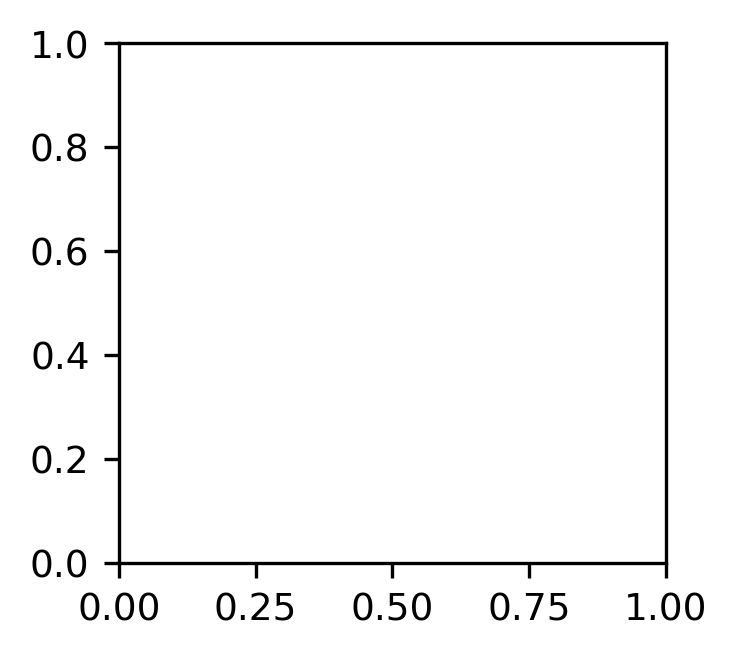

In [24]:
fig = plt.figure(figsize=(8,2.25))

for i in range(len(to_plot)):
    elem = to_plot[i]
    idx = i%3+1
    ax = plt.subplot(1, 3, idx)

    if i//3==0:
        color, line, lab = ['tab:blue', '-', 'Best ADP']
    if i//3==1:
        color, line, lab = ['tab:orange', '-', 'Best comp']
    if i//3==2:
        color, line, lab = ['tab:green', '-', 'Best OP']
    if i//3==3:
        color, line, lab = ['black', '--', 'Baseline']

    idx0 =np.argmin(elem['data']['xw'])
    idx1 =np.argmax(elem['data']['xw'])-4

    # idx0=0
    # idx1=len(elem['data']['xw'])+1

    # print(f'idx0: {idx0}, idx1: {idx1}')

    if idx1<idx0:
        xSucPlot = np.hstack((elem['data']['xw'][idx0:],elem['data']['xw'][:idx1]))
        ySucPlot = np.hstack((elem['data']['cf'][idx0:],elem['data']['cf'][:idx1]))
        xPresPlot = elem['data']['xw'][idx1:idx0]
        yPresPlot = elem['data']['cf'][idx1:idx0]

    else :
        xSucPlot = elem['data']['xw'][idx0:idx1]
        ySucPlot = elem['data']['cf'][idx0:idx1]
        xPresPlot = np.hstack((elem['data']['xw'][idx0:],elem['data']['xw'][:idx1]))
        yPresPlot = np.hstack((elem['data']['cf'][idx0:],elem['data']['cf'][:idx1]))

    ax.plot(xSucPlot, ySucPlot*1000, 'o', label=lab, color=color, linestyle=line, linewidth=lw*1.5, 
            markersize=4.5, markevery=20, markerfacecolor='none', markeredgewidth=0.6)
    ax.plot(xPresPlot, yPresPlot*1000, 'x', label=lab, color=color, linestyle=line, linewidth=lw*1.5, 
            markersize=4.5, markevery=20, markerfacecolor='none', markeredgewidth=0.6)
    ax.plot([-10, 10], [0, 0], color='tab:gray', linestyle='--', linewidth=0.4)

    if idx == 1:
        ax.set_ylabel(r'$C_{f}^{ADP} \cdot 10^{-3}$')
        # ax.legend(ncol=2)
    if idx == 2:
        ax.set_ylabel(r'$C_{f}^{OP1} \cdot 10^{-3}$')
        ax.set_yticklabels([])
    if idx == 3:
        ax.set_ylabel(r'$C_{f}^{OP2} \cdot 10^{-3}$')
        ax.set_yticklabels([])
        # ax.legend(frameon=True,framealpha=0).get_frame().set_edgecolor("none")

    ax.set_ylim(-11, 11)
    ax.set_xlim(0, 1.0)
    # ax.set_xlabel('$\\bar{x}$ [-]')
    ax.set_xlabel('$x/c$')

plt.savefig('cf_comparison.pdf',bbox_inches='tight')
plt.show()